<a href="https://colab.research.google.com/github/Lutfiah-s/Komputasi-Paralel-dan-Terdistribusi/blob/main/Modul_5_CUDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modul 5: GPU Computing Dasar – CUDA
## Langkah 1: Setup dan Verifikasi Lingkungan



In [ ]:
import subprocess, os, re
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Verifikasi NVCC
r = subprocess.run(['nvcc','--version'], capture_output=True, text=True)
print('=== NVCC Version ==='); print(r.stdout.strip())

# Info GPU
r2 = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print('\n=== GPU Info ==='); print(r2.stdout)

=== NVCC Version ===
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0

=== GPU Info ===
Wed Jun 10 14:10:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |         

In [ ]:
# Buat direktori kerja
os.makedirs('cuda_files', exist_ok=True)
print('Direktori cuda_files siap.')

# Cek compute capability GPU
r3 = subprocess.run(
    'nvidia-smi --query-gpu=name,compute_cap,memory.total --format=csv,noheader',
    shell=True, capture_output=True, text=True)
print('GPU Details:', r3.stdout.strip())

Direktori cuda_files siap.
GPU Details: Tesla T4, 7.5, 15360 MiB


## Langkah 2: CPU Serial – Baseline

In [ ]:
%%writefile cuda_files/vector_add_cpu.cpp
#include <iostream>
#include <vector>
#include <chrono>
#include <cstdlib>
#include <cmath>

void vector_add_cpu(float* A, float* B, float* C, int N) {
    for (int i = 0; i < N; i++) C[i] = A[i] + B[i];
}

int main(int argc, char* argv[]) {
    int N = (argc > 1) ? atoi(argv[1]) : 10000000;
    std::vector<float> A(N), B(N), C(N);
    srand(42);
    for (int i = 0; i < N; i++) {
        A[i] = (float)rand()/RAND_MAX;
        B[i] = (float)rand()/RAND_MAX;
    }
    auto t0 = std::chrono::high_resolution_clock::now();
    vector_add_cpu(A.data(), B.data(), C.data(), N);
    auto t1 = std::chrono::high_resolution_clock::now();
    double ms = std::chrono::duration<double,std::milli>(t1-t0).count();
    bool ok = true;
    for (int i=0;i<10;i++) if (fabs(C[i]-(A[i]+B[i]))>1e-6){ok=false;break;}
    float bw = (3.0f*N*sizeof(float))/(ms/1000.0f)/1e9;
    printf("N=%d TIME_MS=%.4f BW=%.4f CORRECT=%d\n",N,ms,bw,(int)ok);
    return 0;
}

Writing cuda_files/vector_add_cpu.cpp


In [ ]:
!g++ -O2 -std=c++11 cuda_files/vector_add_cpu.cpp -o cuda_files/vec_cpu
!./cuda_files/vec_cpu 10000000   # uji dengan 10 juta elemen

N=10000000 TIME_MS=10.5721 BW=11.3507 CORRECT=1


## Langkah 3: CPU dengan OpenMP (Parallel Baseline)

In [ ]:
%%writefile cuda_files/vector_add_openmp.cpp
#include <iostream>
#include <vector>
#include <chrono>
#include <cstdlib>
#include <cmath>
#include <omp.h>

int main(int argc, char* argv[]) {
    int N = (argc>1)?atoi(argv[1]):10000000;
    int T = (argc>2)?atoi(argv[2]):4;
    std::vector<float> A(N), B(N), C(N);
    srand(42);
    for (int i=0;i<N;i++){A[i]=(float)rand()/RAND_MAX;B[i]=(float)rand()/RAND_MAX;}
    omp_set_num_threads(T);
    auto t0 = std::chrono::high_resolution_clock::now();
    #pragma omp parallel for
    for (int i=0;i<N;i++) C[i]=A[i]+B[i];
    auto t1 = std::chrono::high_resolution_clock::now();
    double ms = std::chrono::duration<double,std::milli>(t1-t0).count();
    bool ok=true;
    for(int i=0;i<10;i++) if(fabs(C[i]-(A[i]+B[i]))>1e-6){ok=false;break;}
    float bw=(3.0f*N*sizeof(float))/(ms/1000.0f)/1e9;
    printf("N=%d THREADS=%d TIME_MS=%.4f BW=%.4f CORRECT=%d\n",N,T,ms,bw,(int)ok);
    return 0;
}

Writing cuda_files/vector_add_openmp.cpp


In [ ]:
!g++ -O2 -std=c++11 -fopenmp cuda_files/vector_add_openmp.cpp -o cuda_files/vec_omp
!./cuda_files/vec_omp 10000000 4   # 10M elemen, 4 thread

N=10000000 THREADS=4 TIME_MS=12.1850 BW=9.8482 CORRECT=1


## Langkah 4: CUDA Basic – GPU Kernel

In [ ]:
## Langkah 4: CUDA Basic – GPU Kernel
%%writefile cuda_files/vector_add_cuda.cu
#include <iostream>
#include <cuda_runtime.h>
#include <cstdlib>
#include <cmath>

#define CHECK(call) { \
  cudaError_t e = call; \
  if (e != cudaSuccess) { \
    fprintf(stderr,"CUDA error %s:%d: %s\n", \
            __FILE__, __LINE__, cudaGetErrorString(e)); \
    exit(1); \
  } \
}

// ─── CUDA Kernel ─────────────────────────────────
__global__ void vec_add(float* A, float* B, float* C, int N) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < N) C[idx] = A[idx] + B[idx];
}

int main(int argc, char* argv[]) {
    int N   = (argc>1) ? atoi(argv[1]) : 10000000;
    int TPB = (argc>2) ? atoi(argv[2]) : 256;  // threads per block
    size_t sz = N * sizeof(float);

    // ─── Alokasi Host ────────────────────────────
    float *h_A=new float[N], *h_B=new float[N], *h_C=new float[N];
    srand(42);
    for(int i=0;i<N;i++){h_A[i]=(float)rand()/RAND_MAX;h_B[i]=(float)rand()/RAND_MAX;}

    // ─── Alokasi Device ──────────────────────────
    float *d_A,*d_B,*d_C;
    CHECK(cudaMalloc(&d_A,sz)); CHECK(cudaMalloc(&d_B,sz)); CHECK(cudaMalloc(&d_C,sz));

    // ─── CUDA Events untuk timing ────────────────
    cudaEvent_t ev0,ev1; CHECK(cudaEventCreate(&ev0)); CHECK(cudaEventCreate(&ev1));
    float t_htod, t_kernel, t_dtoh;

    // HtoD transfer
    CHECK(cudaEventRecord(ev0));
    CHECK(cudaMemcpy(d_A,h_A,sz,cudaMemcpyHostToDevice));
    CHECK(cudaMemcpy(d_B,h_B,sz,cudaMemcpyHostToDevice));
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_htod,ev0,ev1));

    // Kernel launch
    int blocks = (N+TPB-1)/TPB;
    CHECK(cudaEventRecord(ev0));
    vec_add<<<blocks,TPB>>>(d_A,d_B,d_C,N);
    CHECK(cudaGetLastError());
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_kernel,ev0,ev1));

    // DtoH transfer
    CHECK(cudaEventRecord(ev0));
    CHECK(cudaMemcpy(h_C,d_C,sz,cudaMemcpyDeviceToHost));
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_dtoh,ev0,ev1));

    float total = t_htod + t_kernel + t_dtoh;
    bool ok=true; for(int i=0;i<10;i++) if(fabs(h_C[i]-(h_A[i]+h_B[i]))>1e-6){ok=false;break;}

    printf("N=%d TPB=%d BLOCKS=%d HTOD=%.4f KERNEL=%.4f DTOH=%.4f TOTAL=%.4f CORRECT=%d\n",
           N,TPB,blocks,t_htod,t_kernel,t_dtoh,total,(int)ok);

    delete[]h_A;delete[]h_B;delete[]h_C;
    CHECK(cudaFree(d_A));CHECK(cudaFree(d_B));CHECK(cudaFree(d_C));
    CHECK(cudaEventDestroy(ev0));CHECK(cudaEventDestroy(ev1));
    return 0;
}

Writing cuda_files/vector_add_cuda.cu


In [ ]:
!nvcc -O2 -std=c++11 cuda_files/vector_add_cuda.cu -o cuda_files/vec_cuda
!./cuda_files/vec_cuda 10000000 256   # 10M elemen, 256 thread per block

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
N=10000000 TPB=256 BLOCKS=39063 HTOD=17.8923 KERNEL=104.3455 DTOH=26.0864 TOTAL=148.3242 CORRECT=1


## Langkah 5: CUDA Pinned Memory – Transfer Lebih Cepat

In [ ]:
%%writefile cuda_files/vector_add_pinned.cu
#include <iostream>
#include <cuda_runtime.h>
#include <cstdlib>
#include <cmath>

#define CHECK(call) do { \
    cudaError_t e = call; \
    if (e != cudaSuccess) { \
        fprintf(stderr, "CUDA error %s:%d: %s\n", \
                __FILE__, __LINE__, cudaGetErrorString(e)); \
        exit(EXIT_FAILURE); \
    } \
} while(0)

__global__ void vec_add(float* A, float* B, float* C, int N) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < N) C[idx] = A[idx] + B[idx];
}

int main(int argc, char* argv[]) {
    int N   = (argc>1) ? atoi(argv[1]) : 10000000;
    int TPB = (argc>2) ? atoi(argv[2]) : 256;
    size_t sz = N * sizeof(float);

    // ─── Pinned memory (page-locked) ─────────────
    float *h_A, *h_B, *h_C;
    CHECK(cudaHostAlloc(&h_A, sz, cudaHostAllocDefault));
    CHECK(cudaHostAlloc(&h_B, sz, cudaHostAllocDefault));
    CHECK(cudaHostAlloc(&h_C, sz, cudaHostAllocDefault));
    srand(42);
    for(int i=0;i<N;i++){h_A[i]=(float)rand()/RAND_MAX;h_B[i]=(float)rand()/RAND_MAX;}

    float *d_A,*d_B,*d_C;
    CHECK(cudaMalloc(&d_A,sz)); CHECK(cudaMalloc(&d_B,sz)); CHECK(cudaMalloc(&d_C,sz));

    cudaEvent_t ev0,ev1; CHECK(cudaEventCreate(&ev0)); CHECK(cudaEventCreate(&ev1));
    float t_htod, t_kernel, t_dtoh;

    CHECK(cudaEventRecord(ev0));
    CHECK(cudaMemcpy(d_A,h_A,sz,cudaMemcpyHostToDevice));
    CHECK(cudaMemcpy(d_B,h_B,sz,cudaMemcpyHostToDevice));
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_htod,ev0,ev1));

    int blocks=(N+TPB-1)/TPB;
    CHECK(cudaEventRecord(ev0));
    vec_add<<<blocks,TPB>>>(d_A,d_B,d_C,N);
    CHECK(cudaGetLastError());
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_kernel,ev0,ev1));

    CHECK(cudaEventRecord(ev0));
    CHECK(cudaMemcpy(h_C,d_C,sz,cudaMemcpyDeviceToHost));
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_dtoh,ev0,ev1));

    float total=t_htod+t_kernel+t_dtoh;
    bool ok=true; for(int i=0;i<10;i++) if(fabs(h_C[i]-(h_A[i]+h_B[i]))>1e-6){ok=false;break;}
    printf("N=%d TPB=%d HTOD=%.4f KERNEL=%.4f DTOH=%.4f TOTAL=%.4f CORRECT=%d\n",
           N,TPB,t_htod,t_kernel,t_dtoh,total,(int)ok);

    CHECK(cudaFreeHost(h_A)); CHECK(cudaFreeHost(h_B)); CHECK(cudaFreeHost(h_C));
    CHECK(cudaFree(d_A)); CHECK(cudaFree(d_B)); CHECK(cudaFree(d_C));
    CHECK(cudaEventDestroy(ev0)); CHECK(cudaEventDestroy(ev1));
    return 0;
}

Writing cuda_files/vector_add_pinned.cu


In [ ]:
!nvcc -O2 -std=c++11 cuda_files/vector_add_pinned.cu -o cuda_files/vec_pinned
!./cuda_files/vec_pinned 10000000 256

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
N=10000000 TPB=256 HTOD=6.5420 KERNEL=0.6682 DTOH=3.0666 TOTAL=10.2767 CORRECT=1


## Langkah 6: Eksperimen Otomatis – Variasi Ukuran Data

In [ ]:
def parse_cpu(out):
    d={}
    for tok in out.split():
        if '=' in tok: k,v=tok.split('='); d[k]=v
    return d

def parse_cuda(out):
    d={}
    for tok in out.split():
        if '=' in tok: k,v=tok.split('='); d[k]=v
    return d

sizes = [1_000, 10_000, 100_000, 1_000_000, 10_000_000, 100_000_000]
results = []

for N in sizes:
    row = {'N': N}
    # CPU Serial
    r = subprocess.run(f'./cuda_files/vec_cpu {N}',   shell=True,capture_output=True,text=True)
    d = parse_cpu(r.stdout); row['cpu_ms']  = float(d.get('TIME_MS',0))
    # OpenMP (4 thread)
    r = subprocess.run(f'./cuda_files/vec_omp {N} 4', shell=True,capture_output=True,text=True)
    d = parse_cpu(r.stdout); row['omp_ms']  = float(d.get('TIME_MS',0))
    # CUDA Basic
    r = subprocess.run(f'./cuda_files/vec_cuda {N} 256',shell=True,capture_output=True,text=True)
    d = parse_cuda(r.stdout)
    row['cuda_htod']   = float(d.get('HTOD',0))
    row['cuda_kernel'] = float(d.get('KERNEL',0))
    row['cuda_dtoh']   = float(d.get('DTOH',0))
    row['cuda_total']  = float(d.get('TOTAL',0))
    # CUDA Pinned
    # CUDA Pinned
    r = subprocess.run(f'./cuda_files/vec_pinned {N} 256',
                      shell=True,capture_output=True,text=True)

    d = parse_cuda(r.stdout)

    row['pinned_htod']   = float(d.get('HTOD',0))
    row['pinned_kernel'] = float(d.get('KERNEL',0))
    row['pinned_dtoh']   = float(d.get('DTOH',0))
    row['pinned_total']  = float(d.get('TOTAL',0))

    results.append(row)
    # SPEEDUP
    row['speedup_omp']    = row['cpu_ms'] / row['omp_ms']
    row['speedup_cuda']   = row['cpu_ms'] / row['cuda_total']
    row['speedup_pinned'] = row['cpu_ms'] / row['pinned_total']

    # GFLOPS
    row['cpu_gflops'] = N / ((row['cpu_ms']/1000)*1e9)
    row['omp_gflops'] = N / ((row['omp_ms']/1000)*1e9)

    if row['cuda_kernel'] > 0:
        row['cuda_gflops'] = N / ((row['cuda_kernel']/1000)*1e9)
    else:
        row['cuda_gflops'] = 0

    if row['pinned_kernel'] > 0:
        row['pinned_gflops'] = N / ((row['pinned_kernel']/1000)*1e9)
    else:
        row['pinned_gflops'] = 0

df = pd.DataFrame(results)
print("\nTABEL 3.4 BREAKDOWN CUDA")

display(
    df[
        [
            'N',
            'cuda_htod',
            'cuda_kernel',
            'cuda_dtoh',
            'pinned_htod',
            'pinned_kernel',
            'pinned_dtoh'
        ]
    ]
)

print("\nTABEL 3.6 SPEEDUP")

display(
    df[
        [
            'N',
            'speedup_omp',
            'speedup_cuda',
            'speedup_pinned'
        ]
    ]
)

row = df[df['N']==10000000].iloc[0]

dist = pd.DataFrame({
    'Komponen':['HtoD','Kernel','DtoH'],
    'Waktu (ms)':[
        row['cuda_htod'],
        row['cuda_kernel'],
        row['cuda_dtoh']
    ]
})

dist['% dari Total'] = (
    dist['Waktu (ms)'] /
    row['cuda_total'] * 100
)

print("\nTABEL 3.5 DISTRIBUSI WAKTU CUDA")

display(dist)

print("\nTABEL 5.4 GFLOPS")

display(
    df[
        [
            'N',
            'cpu_gflops',
            'omp_gflops',
            'cuda_gflops',
            'pinned_gflops'
        ]
    ]
)
print('\n=== Eksperimen selesai ===')


TABEL 3.4 BREAKDOWN CUDA


,N,cuda_htod,cuda_kernel,cuda_dtoh,pinned_htod,pinned_kernel,pinned_dtoh
0,1000,0.0265,0.1487,0.0167,0.0297,0.1447,0.0139
1,10000,0.0555,0.1423,0.0489,0.0362,0.1490,0.0146
2,100000,0.3106,0.1521,0.3030,0.1108,0.1908,0.0432
3,1000000,1.9582,0.1920,2.6675,0.6791,0.2172,0.3182
4,10000000,16.9181,0.6156,25.5532,6.5093,0.6645,3.0547
5,100000000,168.1643,4.7532,258.4537,64.6854,4.7953,30.4186



TABEL 3.6 SPEEDUP


,N,speedup_omp,speedup_cuda,speedup_pinned
0,1000,0.004560,0.003648,0.003717
1,10000,0.025820,0.019457,0.024012
2,100000,0.228077,0.080852,0.179524
3,1000000,0.929065,0.175893,0.697793
4,10000000,1.152614,0.246486,1.038305
5,100000000,1.265961,0.268404,1.158986



TABEL 3.5 DISTRIBUSI WAKTU CUDA


,Komponen,Waktu (ms),% dari Total
0,HtoD,16.9181,39.265067
1,Kernel,0.6156,1.428741
2,DtoH,25.5532,59.306193



TABEL 5.4 GFLOPS


,N,cpu_gflops,omp_gflops,cuda_gflops,pinned_gflops
0,1000,1.428571,0.006515,0.006725,0.006911
1,10000,2.083333,0.053792,0.070274,0.067114
2,100000,1.615509,0.368460,0.657462,0.524109
3,1000000,1.180080,1.096371,5.208333,4.604052
4,10000000,0.941593,1.085293,16.244314,15.048909
5,100000000,0.863693,1.093402,21.038458,20.853753



=== Eksperimen selesai ===


In [ ]:
# Hitung Speedup dan Bandwidth
df['speedup_omp']    = df['cpu_ms'] / df['omp_ms']
df['speedup_cuda']   = df['cpu_ms'] / df['cuda_total']
df['speedup_pinned'] = df['cpu_ms'] / df['pinned_total']
df['pcie_bw_cuda']   = (2*df['N']*4/1e9) / (df['cuda_htod']+df['cuda_dtoh'])*1000  # GB/s
df['pcie_bw_pinned'] = (2*df['N']*4/1e9) / df['pinned_total']*1000

# Cetak tabel ringkasan
print('=== Tabel Waktu Eksekusi (ms) ===')
print(df[['N','cpu_ms','omp_ms','cuda_total','pinned_total']].to_string(index=False))
print('\n=== Tabel Speedup ===')
print(df[['N','speedup_omp','speedup_cuda','speedup_pinned']].to_string(index=False))

=== Tabel Waktu Eksekusi (ms) ===
        N   cpu_ms  omp_ms  cuda_total  pinned_total
     1000   0.0007  0.1535      0.1919        0.1883
    10000   0.0048  0.1859      0.2467        0.1999
   100000   0.0619  0.2714      0.7656        0.3448
  1000000   0.8474  0.9121      4.8177        1.2144
 10000000  10.6203  9.2141     43.0869       10.2285
100000000 115.7819 91.4577    431.3712       99.8993

=== Tabel Speedup ===
        N  speedup_omp  speedup_cuda  speedup_pinned
     1000     0.004560      0.003648        0.003717
    10000     0.025820      0.019457        0.024012
   100000     0.228077      0.080852        0.179524
  1000000     0.929065      0.175893        0.697793
 10000000     1.152614      0.246486        1.038305
100000000     1.265961      0.268404        1.158986


## Langkah 7: Visualisasi Hasil

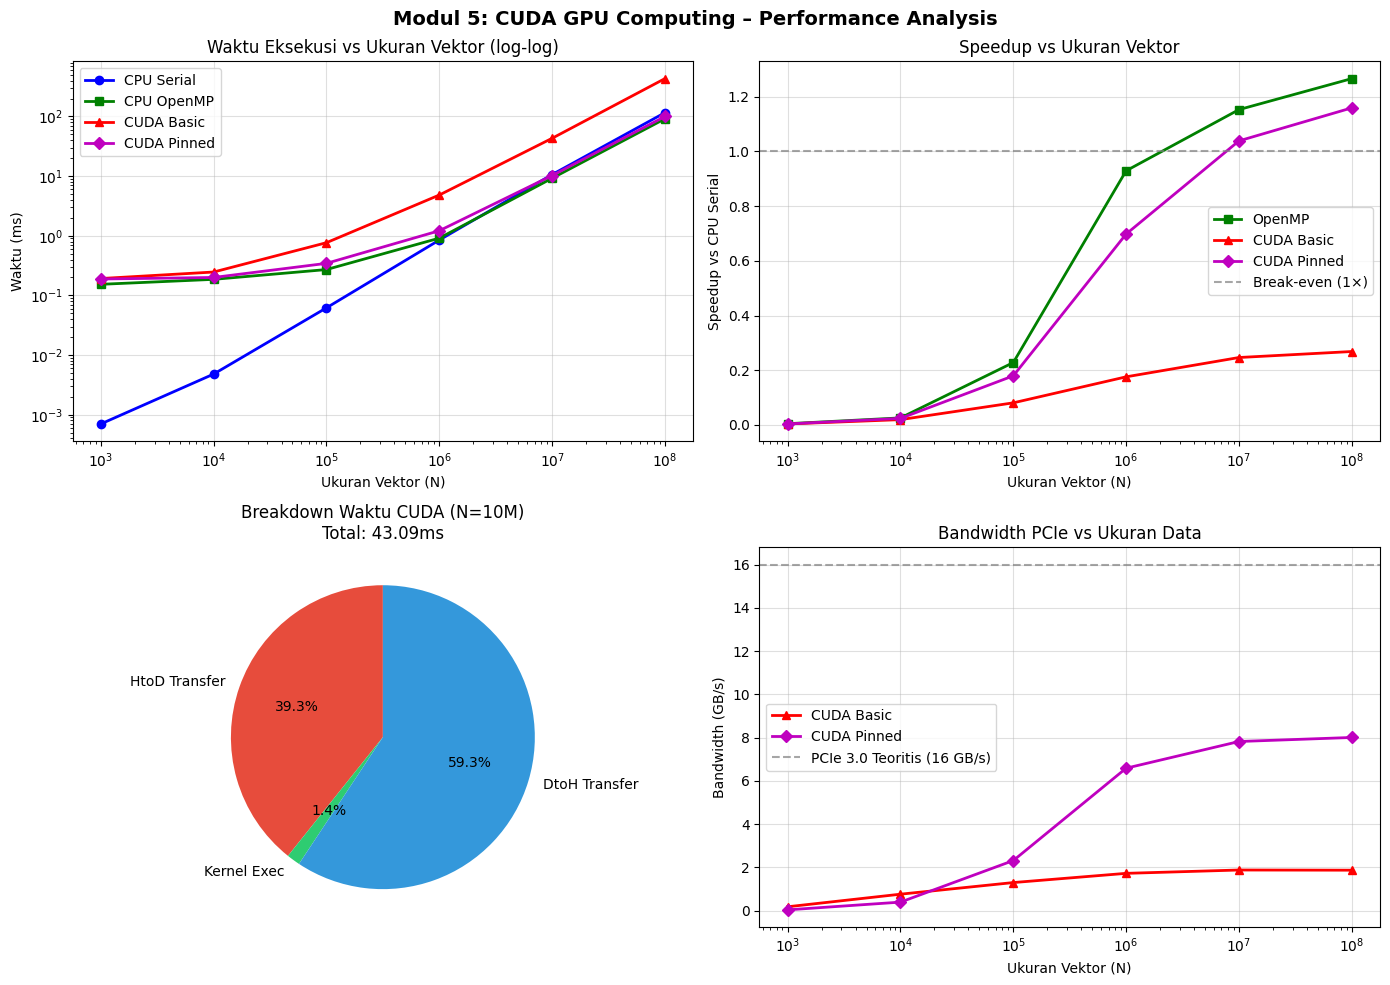

Grafik disimpan ke cuda_files/performance_analysis.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sizes_k = [f'{n//1000}K' if n<1e6 else f'{n//1000000}M' for n in df['N']]

# Grafik 1: Waktu Eksekusi (log scale)
ax = axes[0,0]
ax.loglog(df['N'], df['cpu_ms'],    'b-o', label='CPU Serial',  linewidth=2)
ax.loglog(df['N'], df['omp_ms'],    'g-s', label='CPU OpenMP',  linewidth=2)
ax.loglog(df['N'], df['cuda_total'],'r-^', label='CUDA Basic',  linewidth=2)
ax.loglog(df['N'], df['pinned_total'],'m-D',label='CUDA Pinned',linewidth=2)
ax.set_xlabel('Ukuran Vektor (N)'); ax.set_ylabel('Waktu (ms)')
ax.set_title('Waktu Eksekusi vs Ukuran Vektor (log-log)'); ax.legend(); ax.grid(True,alpha=0.4)

# Grafik 2: Speedup vs CPU Serial
ax = axes[0,1]
ax.semilogx(df['N'], df['speedup_omp'],   'g-s', label='OpenMP',      linewidth=2)
ax.semilogx(df['N'], df['speedup_cuda'],  'r-^', label='CUDA Basic',  linewidth=2)
ax.semilogx(df['N'], df['speedup_pinned'],'m-D', label='CUDA Pinned', linewidth=2)
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.7, label='Break-even (1×)')
ax.set_xlabel('Ukuran Vektor (N)'); ax.set_ylabel('Speedup vs CPU Serial')
ax.set_title('Speedup vs Ukuran Vektor'); ax.legend(); ax.grid(True,alpha=0.4)

# Grafik 3: CUDA Breakdown (10M elemen)
ax = axes[1,0]
row10m = df[df['N']==10_000_000].iloc[0]
labels_b = ['HtoD Transfer','Kernel Exec','DtoH Transfer']
vals_b = [row10m['cuda_htod'], row10m['cuda_kernel'], row10m['cuda_dtoh']]
colors_b = ['#E74C3C','#2ECC71','#3498DB']
wedges,texts,autotexts = ax.pie(vals_b, labels=labels_b, colors=colors_b,
    autopct='%1.1f%%', startangle=90, textprops={'fontsize':10})
ax.set_title(f'Breakdown Waktu CUDA (N=10M)\nTotal: {row10m["cuda_total"]:.2f}ms')

# Grafik 4: Bandwidth PCIe
ax = axes[1,1]
ax.semilogx(df['N'], df['pcie_bw_cuda'],   'r-^', label='CUDA Basic',  linewidth=2)
ax.semilogx(df['N'], df['pcie_bw_pinned'], 'm-D', label='CUDA Pinned', linewidth=2)
ax.axhline(y=16, color='gray', linestyle='--', alpha=0.7, label='PCIe 3.0 Teoritis (16 GB/s)')
ax.set_xlabel('Ukuran Vektor (N)'); ax.set_ylabel('Bandwidth (GB/s)')
ax.set_title('Bandwidth PCIe vs Ukuran Data'); ax.legend(); ax.grid(True,alpha=0.4)

plt.suptitle('Modul 5: CUDA GPU Computing – Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cuda_files/performance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan ke cuda_files/performance_analysis.png')

## Langkah 8: Eksperimen Konfigurasi Thread per Block

TPB=   32: kernel=0.9517ms  total=43.6763ms
TPB=   64: kernel=0.6163ms  total=43.4533ms
TPB=  128: kernel=0.6262ms  total=43.4489ms
TPB=  256: kernel=0.6095ms  total=43.5970ms
TPB=  512: kernel=0.6113ms  total=43.4706ms
TPB= 1024: kernel=0.6084ms  total=43.4531ms

=== Tabel Thread per Block ===
 ThreadsPerBlock  Blocks  Kernel_ms  Total_ms
              32  312500     0.9517   43.6763
              64  156250     0.6163   43.4533
             128   78125     0.6262   43.4489
             256   39063     0.6095   43.5970
             512   19532     0.6113   43.4706
            1024    9766     0.6084   43.4531


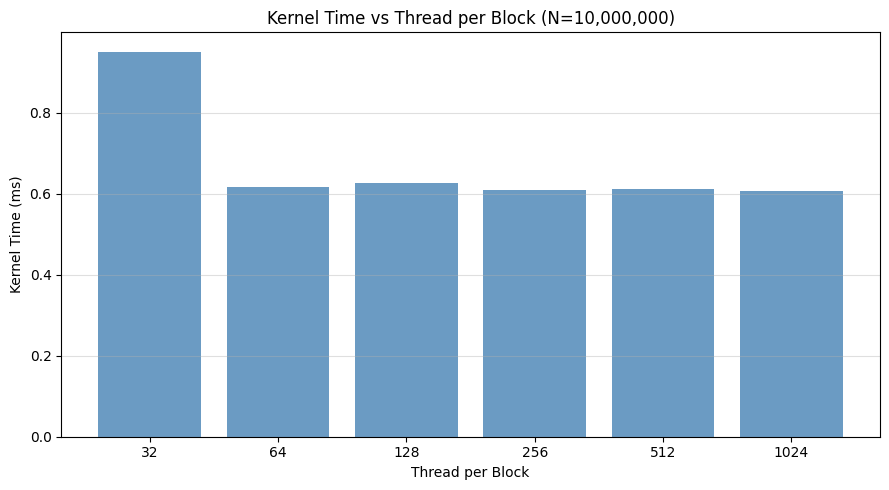

In [ ]:
tpb_configs = [32, 64, 128, 256, 512, 1024]
N_test = 10_000_000
tpb_results = []

for tpb in tpb_configs:
    r = subprocess.run(f'./cuda_files/vec_cuda {N_test} {tpb}',
                       shell=True, capture_output=True, text=True)
    d = parse_cuda(r.stdout)
    tpb_results.append({
        'ThreadsPerBlock': tpb,
        'Blocks'         : int(d.get('BLOCKS', 0)),
        'Kernel_ms'      : float(d.get('KERNEL',0)),
        'Total_ms'       : float(d.get('TOTAL',0))
    })
    print(f'TPB={tpb:5d}: kernel={float(d.get("KERNEL",0)):.4f}ms  total={float(d.get("TOTAL",0)):.4f}ms')

df_tpb = pd.DataFrame(tpb_results)
print('\n=== Tabel Thread per Block ===')
print(df_tpb.to_string(index=False))

# Visualisasi
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(range(len(tpb_configs)), df_tpb['Kernel_ms'], color='steelblue', alpha=0.8)
ax.set_xticks(range(len(tpb_configs)))
ax.set_xticklabels([str(t) for t in tpb_configs])
ax.set_xlabel('Thread per Block'); ax.set_ylabel('Kernel Time (ms)')
ax.set_title(f'Kernel Time vs Thread per Block (N={N_test:,})')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.savefig('cuda_files/tpb_analysis.png', dpi=150, bbox_inches='tight')
plt.show()